# EnrichMap resolves opposing gene programmes

This tutorial demonstrates how to use `EnrichMap` when the upregulated and downregulated gene programmes are known for the pathway of interest.

In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

Import required packages for minimal example.

In [3]:
import scanpy as sc
import enrichmap as em

In [4]:
sc.set_figure_params(frameon=False)

Read in the dataset:

In [5]:
adata = sc.read(
    "adata_breast.h5ad",
    backup_url="https://github.com/secrierlab/EnrichMap/raw/main/tests/dataset/adata_breast.h5ad",
)

As the data is shared as raw counts, we normalise them.

In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

Here, we investigate G0 arrest in breast cancer. The gene signature is taken from [Wiecek et al (2023)](https://link.springer.com/article/10.1186/s13059-023-02963-4).

In [7]:
upregulated_genes = [
    "CFLAR", "CALCOCO1", "YPEL3", "CST3", "SERINC1", "CLIP4", "PCYOX1", "TMEM59",
    "RGS2", "YPEL5", "CD63", "KIAA1109", "CDH13", "GSN", "MR1", "CYB5R1", "AZGP1",
    "ZFYVE1", "DMXL1", "EPS8L2", "PTTG1IP", "MIR22HG", "PSAP", "GOLGA8B", "NEAT1",
    "TXNIP", "MTRNR2L12"
]

downregulated_genes = [
    "NCAPD2", "PTBP1", "MPHOSPH9", "NUCKS1", "TCOF1", "SART3", "SNRPA", "KIF22",
    "HSP90AA1", "WBP11", "CAD", "SF3B2", "KHSRP", "WDR76", "NUP188", "HSP90AB1",
    "HNRNPM", "SMARCB1", "PNN", "RBBP7", "NPRL3", "USP10", "SGTA", "MRPL4", "PSMD3",
    "KPNB1", "CBX1", "LRRC59", "TMEM97", "NSD2", "PRPF19", "PTGES3", "CPSF6", "SRSF3",
    "TCERG1", "SMC4", "EIF4G1", "ZNF142", "MSH6", "MRPL37", "SFPQ", "STMN1", "ARID1A",
    "PROSER1", "DDX39A", "EXOSC9", "USP22", "DEK", "DUT", "ILF3", "DNMT1", "NASP",
    "HMGB1P5", "SRRM1", "GNL2", "RNF138", "SRSF1", "TRA2B", "SMPD4", "ANP32B", "HMGA1",
    "MDC1", "HADH", "ARHGDIA", "PRCC", "HDGF", "SF3B4", "UBAP2L", "ILF2", "PARP1",
    "LBR", "CNOT9", "PPRC1", "SSRP1", "CCT5", "DLAT", "HNRNPU", "LARP1", "SCAF4",
    "RRP1B", "RRP1", "CHCHD4", "GMPS", "RFC4", "SLBP", "PSIP1", "HNRNPK", "SKA3",
    "DIS3L", "USP39", "GPS1", "PA2G4", "HCFC1", "SLC19A1", "ETV4", "RAD23A", "DCTPP1",
    "RCC1", "EWSR1", "ALYREF", "PTMA", "HMGB1", "POM121", "MCMBP", "TEAD4", "CHAMP1",
    "TOP1", "PRRC2A", "RBM14", "HMGB1P6", "POM121C", "UHRF1"
]

We first build directional gene weights using the `upregulated_genes` and `downregulated_genes` lists in the G0 programme. The `build_signed_weights()` function computes CV-based magnitudes and uses differential spatial correlation against the upregulated and downregulated reference patterns to assign signed weights.

In [8]:
directional_gene_weight_dict = em.tl.build_signed_weights(adata, up_genes=upregulated_genes, down_genes=downregulated_genes, score_key="enrichmap")

We now calculate `EnrichMap` scores for the G0 arrest programme. As there is more than one slide in this dataset, we specify the batch information stored in `adata.obs`. Note that when using weighted signatures, we use the `gene_weights` argument instead of `gene_set`.

In [9]:
em.tl.score(adata, gene_weights=directional_gene_weight_dict, batch_key="batch")

Scoring enrichmap: 126/126 genes found: 100%|██████████| 1/1 [00:02<00:00,  2.15s/it]


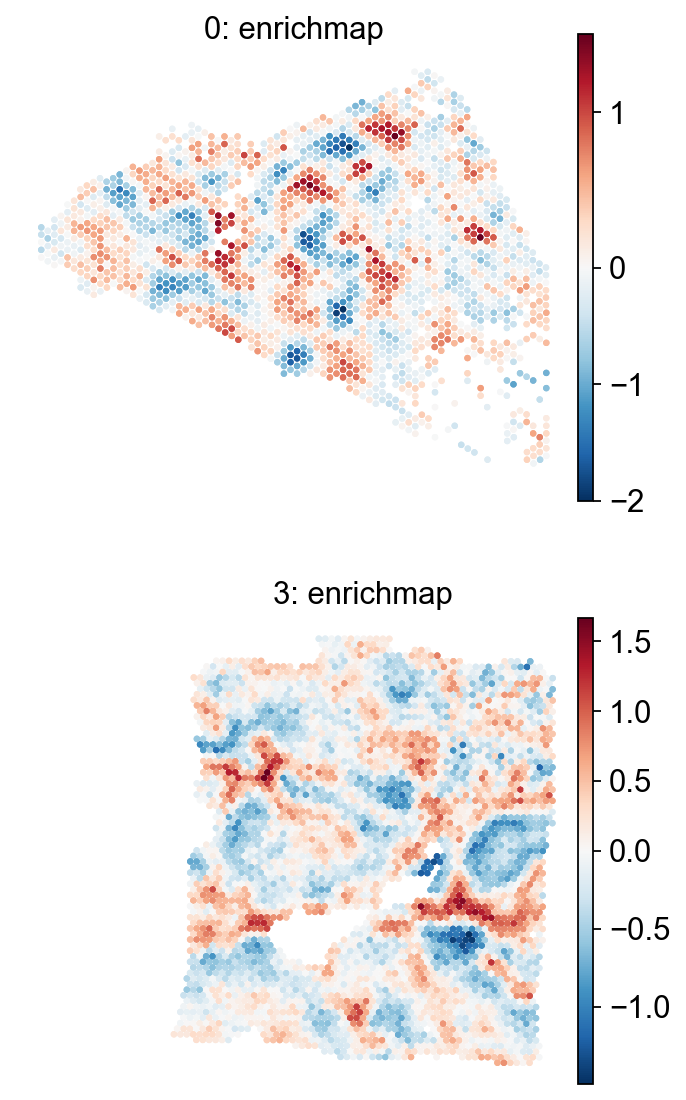

In [10]:
em.pl.spatial_enrichmap(
    adata,
    score_key=["enrichmap_score"],
    size=2,
    library_key="batch",
    library_id=["0", "3"],
    cmap="RdBu_r",
    shape=None
)

## Evaluate spatial autocorrelation

We can assess the spatial structure of the G0 arrest score using a Moran's scatter plot.

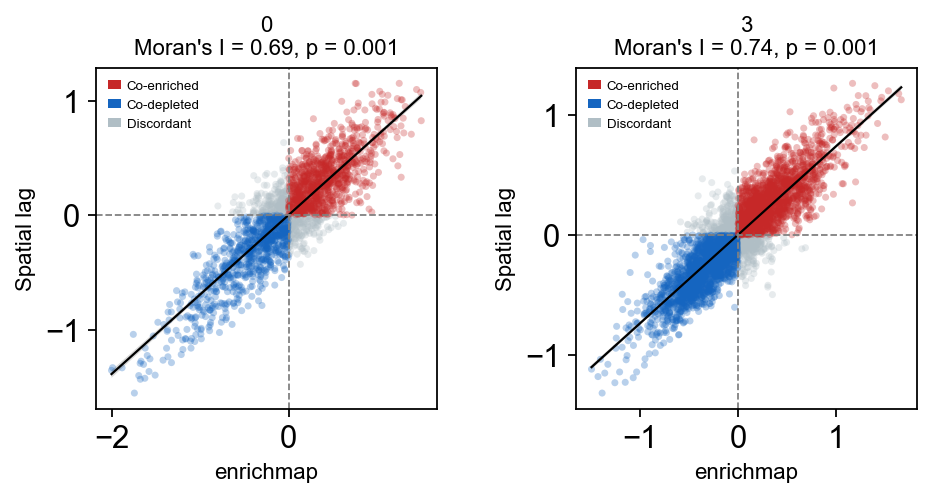

In [11]:
em.pl.morans_correlogram(
    adata,
    score_key="enrichmap_score",
    library_key="batch",
    library_id=["0", "3"]
)

The Moran's scatter plot confirms spatial autocorrelation of the signed G0 arrest score, with co-enriched and co-depleted spots clustering as expected.